# Coffee Consumption and Happiness: Are They Related?

This blog explores whether domestic coffee consumption is associated with national happiness. This analysis uses:

- International Coffee Organisation (ICO) consumption data
- World Happiness Report (2019) rankings
- Several python libraries (pandas, matplot and statsmodels)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

coffee = pd.read_csv("../data/cooked/coffee_domestic_consumption_cooked.csv")
happiness = pd.read_csv("../data/cleaned/happiness_2019_cleaned.csv")
merged = pd.read_csv("../data/cleaned/coffee_and_happiness_2019.csv")

## Data Samples

Below are some examples of the base data. (May need to run them and the code above to view)
The units for the value of the coffee is measured in kilograms.

In [3]:
coffee.head()

,country,coffee_type,year_raw,value,year
0,Angola,Robusta/Arabica,1990/91,1200000,1990
1,Bolivia (Plurinational State of),Arabica,1990/91,1500000,1990
2,Brazil,Arabica/Robusta,1990/91,492000000,1990
3,Burundi,Arabica/Robusta,1990/91,120000,1990
4,Ecuador,Arabica/Robusta,1990/91,21000000,1990


In [4]:
happiness.head()

,country,happiness_rank,year
0,Finland,1,2019
1,Denmark,2,2019
2,Norway,3,2019
3,Iceland,4,2019
4,Netherlands,5,2019


## Data Cleaning Summary

The following steps were applied in the preprocessing scripts:

- Standardised country names
- Converted year formats (e.g., "2019/20" into "2019")
- Removed missing or inconsistent entries
- Extracted 2019 happiness rankings
- Merged coffee consumption with happiness data

The cleaned datasets are used for all analysis below.

In [5]:
merged.head()

,country,coffee_type,year_raw,value,year_x,happiness_rank,year_y
0,Brazil,Arabica/Robusta,2019/20,1320000000,2019,32,2019
1,Burundi,Arabica/Robusta,2019/20,120000,2019,145,2019
2,Ecuador,Arabica/Robusta,2019/20,8940000,2019,50,2019
3,Indonesia,Robusta/Arabica,2019/20,288360000,2019,92,2019
4,Madagascar,Robusta,2019/20,22500000,2019,143,2019


## Top 5 Coffee Consumers Over Time

This plot shows the top five all‑time coffee‑consuming countries and how their consumption has evolved over time. 
Units are converted to billions for readability.

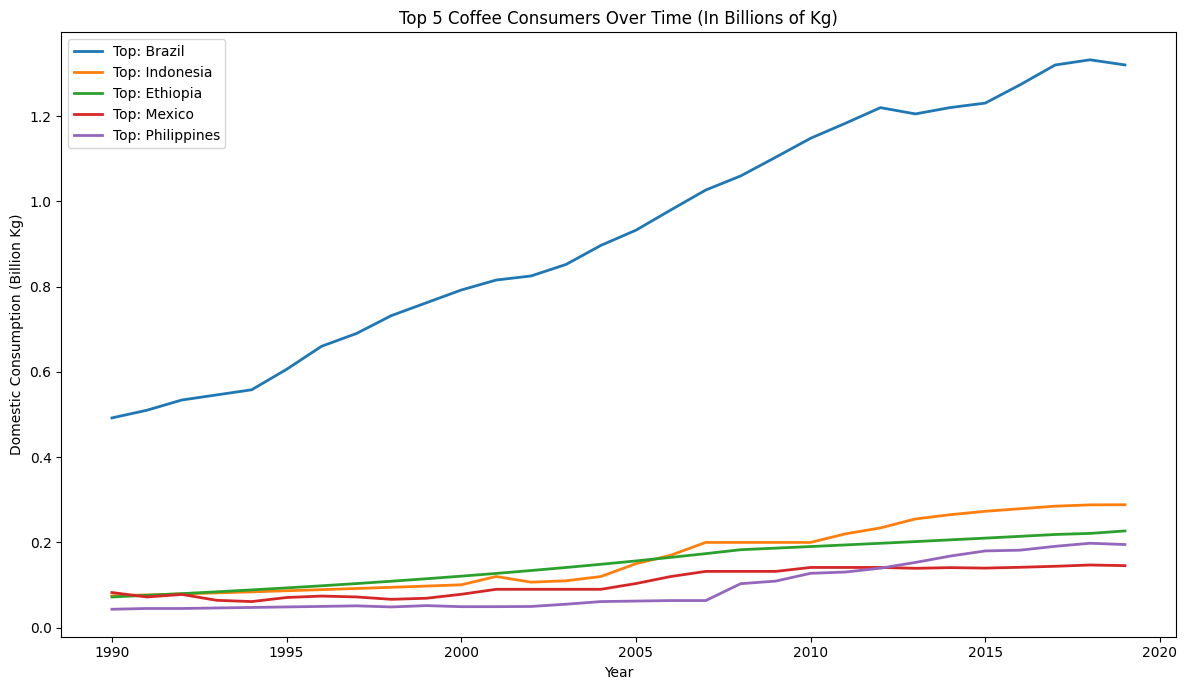

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cooked/coffee_domestic_consumption_cooked.csv")

# Compute total consumption across all years, because it's easier
totals = df.groupby("country")["value"].sum().sort_values(ascending=False)

top5_countries = totals.head(5).index.tolist()

df_top5 = df[df["country"].isin(top5_countries)].copy()

# Convert units to billions
df_top5["value_billion"] = df_top5["value"] / 1_000_000_000

plt.figure(figsize=(12, 7))

# Plot top 5
for c in top5_countries:
    subset = df_top5[df_top5["country"] == c]
    plt.plot(subset["year"], subset["value_billion"], label=f"Top: {c}", linewidth=2)

plt.title("Top 5 Coffee Consumers Over Time (In Billions of Kg)")
plt.xlabel("Year")
plt.ylabel("Domestic Consumption (Billion Kg)")
plt.legend()
plt.tight_layout()
plt.show()

## Year-on-Year Growth Rates

Growth rates show how volatile or stable consumption is across countries and how demand can be affected by shocks.
This plot focuses on the top five all‑time consumers.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cooked/coffee_domestic_consumption_cooked.csv")

# Sort
df = df.sort_values(["country", "year"])

# Compute growth
df["yoy_growth"] = df.groupby("country")["value"].pct_change()

# Top 5 all-time consumers
totals = df.groupby("country")["value"].sum().sort_values(ascending=False)
top5 = totals.head(5).index.tolist()

plt.figure(figsize=(12, 7))

for c in top5:
    subset = df[df["country"] == c]
    plt.plot(subset["year"], subset["yoy_growth"], label=c)

plt.title("Year-on-Year Growth Rates for Top 5 Coffee Consumers")
plt.xlabel("Year")
plt.ylabel("Growth Rate")
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'data/cooked/coffee_domestic_consumption_cooked.csv'

## Coffee Consumption vs Happiness Rank (2019)

This scatter plot shows the relationship between coffee consumption (in billions) and happiness rank (lower = happier). This is due to the form that the happiness data came in.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/cleaned/coffee_and_happiness_2019.csv")
# Convert to billions
df["value_billion"] = df["value"] / 1_000_000_000

plt.figure(figsize=(8,6))
plt.scatter(df["value_billion"], df["happiness_rank"])
plt.xlabel("Coffee Consumption (Billion Kg, 2019)")
plt.ylabel("Happiness Rank (2019)")
plt.title("Coffee Consumption vs Happiness Rank")
plt.gca().invert_yaxis()  # lower rank = happier
plt.show()

## Correlation Analysis

We compute the Pearson correlation between coffee consumption and happiness rank.
A negative value indicates that higher consumption is associated with better (lower) happiness rank.

In [ ]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv("data/cleaned/coffee_and_happiness_2019.csv")

# X = domestic coffee consumption
X = sm.add_constant(df["value"])

# y = happiness rank
y = df["happiness_rank"]

model = sm.OLS(y, X).fit()
print(model.summary())

corr = df["value"].corr(df["happiness_rank"])
print(f"The correlation between happiness rank and consumption of coffee is ", corr,".")

## Interpretation

- The correlation is weak and negative, indicating that higher coffee consumption is associated with slightly better happiness rank.
- The relationship is small in magnitude and should be interpreted cautiously.
- This aligns with the regression output, which also showed a weak negative relationship.
- Overall, coffee consumption does not strongly predict happiness, but there is a mild association.
- As far as regressions go this isn't a great example as the rank is ordinal in scale but can still show the effect coffee has on happiness.

## Conclusion

This analysis explored whether coffee consumption is related to national happiness. 
Using cleaned datasets and a merged 2019 sample, I found:

- A weak negative correlation between consumption and happiness rank
- Top coffee-consuming countries show stable long-term consumption patterns
- Growth rates reveal interesting volatility differences across countries

The results suggest that while coffee consumption may be loosely associated with happiness, it is not a strong predictor on its own.
